# AP 155 Lab Exercise
---
## Exercise 4: Derivatives

_Instructions_: 
- **Report figure (See Problem 1):** Plot of mean absolute error vs. step size (spacing between points) when using the forward, backward, and central difference approach to get first derivative
- **Report discussion:** Explain the results of your figure. How do the central and non-central difference formulas arrive at such accuracies? Looking outward, when is each method of differentiation suitable/appropriate? 
  
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: 
- _Student No._: 20XX-XXXXX
- _Section_: THR-TX-_

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.
https://download.geofabrik.de/asia/philippines-latest-free.shp.ziphttps://download.geofabrik.de/asia/philippines-latest-free.shp.zip
### Report discussion

EDIT ME. See instruction above for what to include. Insert your discussions here. Discuss your key results with ~150 words per question.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1:

Consider the function:
$$ f(x) = 2 + 5x\sin\left(x + \frac{\pi}{4}\right)$$

Say you start with 257 points from 0 to $4\pi$ 

We first find the analytical derivative $f'(x)$:
$$
\begin{align}
f'(x) &= 5x\cos\left(x + \frac{\pi}{4}\right) + 5\sin\left(x + \frac{\pi}{4}\right)
\end{align}
$$

In [2]:
def analytic_diff(x):
    analytic_diff = 5 * x * np.cos(1*x + np.pi/4) + 5 * np.sin(1*x+np.pi/4)
    return analytic_diff

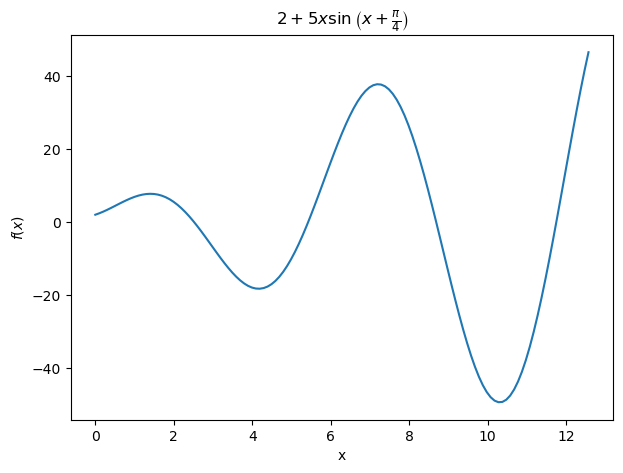

In [3]:
def f(x):
    return 2 + 5*x*np.sin(1*x+np.pi/4)
    
x = np.linspace(0, 4*np.pi, 127)
y = f(x)
    
fig, ax = plt.subplots(figsize = (7,5))
ax.plot(x, y)
ax.set_title(r"$2 + 5x\sin\left(x + \frac{\pi}{4}\right)$")
ax.set_ylabel("$f(x)$")
ax.set_xlabel("x")
fig.show()
fig.savefig('f_x.png')

- Create a function that gets the first derivative approximation using the forward, backward, and central difference formulas. (Bonus, not required): Make the function flexible to non-evenly spaced data

In [4]:
def forward_diff(x=x, f=f):
    h = np.roll(x, -1) - x 
    fi_plus = np.roll(f(x), -1)  
    f_diff = ((fi_plus - f(x)) / h)[:-1]
    return f_diff

def backward_diff(x=x, f=f):
    h = np.roll(x, 1) - x 
    fi = np.roll(f(x), 1)  
    f_diff = ((fi - f(x)) / h)[1:]
    return f_diff
    
def central_diff(x=x, f=f):
    h = np.roll(x, 1) - x 
    fi_plus = np.roll(f(x), 1)  
    fi_minus = np.roll(f(x), -1)  
    f_diff = ((fi_plus - fi_minus) / (2*h))[1:-1]
    return f_diff

- To give yourself a visualization, plot (in a single axis):
  - the three derivative approximations
  - the analytically derived function

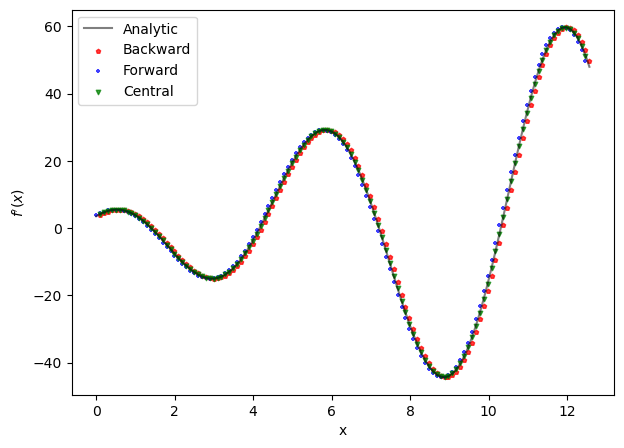

In [5]:
f_prime_back = backward_diff(x, f)
f_prime_forw = forward_diff(x, f)
f_prime_centre = central_diff(x, f)
f_prime_analytic = analytic_diff(x)

derivatives = [(backward_diff, "red", 0.75, "p", "Backward", slice(1, None)), 
               (forward_diff, "blue", 0.75, "+", "Forward", slice(0,-1)), 
               (central_diff, "green", 0.75, "v", "Central", slice(1,-1))]

size = 10
fig, ax = plt.subplots(figsize = (7,5))
ax.plot(x, f_prime_analytic, c="black", alpha=0.5, label="Analytic")
for method, color, alpha, marker, label, slic in derivatives:
    x_s = x
    ax.scatter(x_s[slic], method(x, f), c=color, alpha=alpha, s=size, marker=marker, label=label)
    
ax.legend()
ax.set_ylabel("$f'(x)$")
ax.set_xlabel("x")
plt.show()

- Get the mean absolute error of each of the approximations compared to the analytically derived function

In [6]:
diff = [(backward_diff, slice(1, None)), (forward_diff, slice(0,-1)), (central_diff, slice(1,-1))]

def calculate_mae(x, f, diff):
    may_array = []
    for method, slic in diff:
        # print(f"{method}")
        y = analytic_diff(x)
        MAE = np.mean(np.abs(y[slic] - method(x, f)))
        # print(MAE)
        may_array.append(MAE)
    return may_array
        
maes = calculate_mae(x,f,diff)
maes

[1.0174966173256244, 1.0139103706865906, 0.03976570073967638]

In [ ]:
#resolution = np.array([64, 128, 256, 512, 1028])
resolution = np.logspace(1, 15, 25, dtype=int)
step_size = 4*np.pi/resolution # 4*pi because that is our domain

mga_MAE = []

for res in resolution:
    x = np.linspace(0, 4*np.pi, res)
    y = analytic_diff(x)
    maes = calculate_mae(x, f, diff)
    mga_MAE.append(maes)
    
mga_MAE = np.transpose(mga_MAE)
# print(mga_MAE)
print(resolution)

- Repeat the above step for increasing number of points (decreasing spacing) - instead of 256 points, take 512/1024/128/64 points, etc.

- (For the report) Make a plot of the mean absolute error vs the spacing between points. In this plot, there should be three curves: One for the forward, one for the backward, and one for the central difference approximation

In [ ]:
# print(step_size)
plot_settings = [("red", 0.5, "p", "Backward"), 
                 ("blue", 0.5, "s", "Forward"), 
                 ("green", 0.5, "v", "Central")]

fig, ax = plt.subplots(figsize = (7,5))
for mae, (color, alpha, marker, label) in zip(mga_MAE, plot_settings):
    ax.scatter(step_size, mae, c=color, alpha=alpha, marker=marker, label=label)
    # print(mae)
    
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel("$f'(x)$")
ax.set_xlabel("x")
plt.show()

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

## Section 3 (Notes)

### Non-central difference formulas (First Derivative)

* Forward 
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{x})}{h} + O(h)
$$

* Backward
$$
f'(x_i) = \frac{f(x_{i}) - f(x_{i-1})}{h} + O(h)
$$



### Central-difference formulas

* First Derivative
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{i-1})}{2h} + O(h^2)
$$

* Second Derivative
$$
f''(x_i) = \frac{f(x_{i+1}) - 2f(x_{i}) + f(x_{i-1})}{h^2} + O(h^2)
$$

Note: to avoid confusion, think: $x_i$ is `x[i]`, and $h$ is the gap between `x[i+1]` and `x[i]`.


In [9]:
## Useful tips. Not required to solve the problems below!

# Suppose you have a Numpy array
x = np.linspace(1, 10, 10)
print(x)

# I can move all values to the left/right using roll
x_roll = np.roll(x, -1) # change 1 to -1, what happens? 
x_roll2 = np.roll(x, -1)
print(x_roll)

# then I could exploit array operations to get their difference
x_diff = (x_roll - x)[1:]
print(x_diff)
# Be careful with the boundaries!

x_diff2 = (x_roll2 - x_roll)[:]
print(x_diff2)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[ 2.  3.  4.  5.  6.  7.  8.  9. 10.  1.]
[ 1.  1.  1.  1.  1.  1.  1.  1. -9.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
